# Man vs Machine on Oslo Bors - Simulation


### Data Setup

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set plotting style for professional academic charts
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Load the Predictions Data
df_mod = pd.read_csv('../Data/modern_predictions.csv')
df_hist = pd.read_csv('../Data/historical_predictions.csv')

# Ensure TradeDate is a proper datetime object
df_mod['TradeDate'] = pd.to_datetime(df_mod['TradeDate'])
df_hist['TradeDate'] = pd.to_datetime(df_hist['TradeDate'])

# ---------------------------------------------------------
# THE FIX: Bring back the Traditional Momentum Feature
# ---------------------------------------------------------
print("Fetching original momentum features...")
# Load just the essential columns from the original raw datasets
orig_mod = pd.read_csv('../Data/modern_equity_dataset.csv', usecols=['TradeDate', 'ISIN', 'mom_12m_z'])
orig_hist = pd.read_csv('../Data/investable_universe.csv', usecols=['TradeDate', 'ISIN', 'mom_12m_z'])

orig_mod['TradeDate'] = pd.to_datetime(orig_mod['TradeDate'])
orig_hist['TradeDate'] = pd.to_datetime(orig_hist['TradeDate'])

# Left merge the momentum feature onto our prediction dataframes
df_mod = pd.merge(df_mod, orig_mod, on=['TradeDate', 'ISIN'], how='left')
df_hist = pd.merge(df_hist, orig_hist, on=['TradeDate', 'ISIN'], how='left')

# Sort chronologically just to be safe
df_mod = df_mod.sort_values(['TradeDate', 'ISIN']).reset_index(drop=True)
df_hist = df_hist.sort_values(['TradeDate', 'ISIN']).reset_index(drop=True)

# Define our transaction cost (15 basis points per trade)
TC_BPS = 0.0015 

# Cap the simulation period
SIM_END_DATE = pd.to_datetime('2024-11-30')

# Filter the datasets to the simulation period
df_mod = df_mod[df_mod['TradeDate'] <= SIM_END_DATE]
df_hist = df_hist[df_hist['TradeDate'] <= SIM_END_DATE]

print("Data loaded and Momentum merged successfully!")
print(f"Modern rows: {df_mod.shape[0]} | Historical rows: {df_hist.shape[0]}")

Fetching original momentum features...
Data loaded and Momentum merged successfully!
Modern rows: 10020 | Historical rows: 10020


### Simulation functions

In [46]:
# ==========================================
# PORTFOLIO WEIGHTING FUNCTION
# ==========================================
def get_portfolio_weights(month_df, signal_col, quantile=0.20):
    """
    Takes a dataframe for a single month and returns target portfolio weights.
    Returns weights for both a Long-Only and a Long-Short strategy.
    """
    # 1. Calculate the cutoff thresholds for the top and bottom quantiles
    top_cutoff = month_df[signal_col].quantile(1 - quantile)
    bottom_cutoff = month_df[signal_col].quantile(quantile)
    
    # 2. Identify the exact stocks in the Long and Short baskets
    long_basket = month_df[month_df[signal_col] >= top_cutoff]
    short_basket = month_df[month_df[signal_col] <= bottom_cutoff]
    
    # 3. Calculate weights (Equal Weighting within the baskets)
    # Long-Only: 100% divided equally among the long basket
    n_long = len(long_basket)
    # FIX: Use .index instead of ['ISIN']
    long_only_weights = pd.Series(1.0 / n_long, index=long_basket.index) if n_long > 0 else pd.Series(dtype=float)
    
    # Long-Short: +100% in longs, -100% in shorts (Dollar Neutral)
    n_short = len(short_basket)
    # FIX: Use .index instead of ['ISIN']
    short_weights = pd.Series(-1.0 / n_short, index=short_basket.index) if n_short > 0 else pd.Series(dtype=float)
    
    # Combine long and short for the LS strategy
    long_short_weights = pd.concat([long_only_weights, short_weights])
    
    return long_only_weights, long_short_weights

In [47]:
# ==========================================
# THE BACKTEST ENGINE
# ==========================================
def run_backtest(df, signal_col, quantile=0.20, tc_rate=0.0015):
    """
    Simulates trading month-by-month, accounting for turnover and transaction costs.
    """
    dates = sorted(df['TradeDate'].unique())
    
    # Storage for our results
    results = []
    
    # Track the previous month's weights to calculate turnover
    prev_weights_lo = pd.Series(dtype=float)
    prev_weights_ls = pd.Series(dtype=float)
    
    for date in dates:
        # Get data for the current month
        current_month_data = df[df['TradeDate'] == date].set_index('ISIN')
        
        # 1. Get the target weights based on our ML predictions
        curr_weights_lo, curr_weights_ls = get_portfolio_weights(
            current_month_data, signal_col=signal_col, quantile=quantile
        )
        
        # 2. Get the actual future returns (Target_raw)
        # Remember: Target_raw is already shifted to represent t+1 return!
        future_returns = current_month_data['Target_raw'].fillna(0)
        
        # 3. Calculate Gross Returns (Dot product of weights and returns)
        # Using .reindex().fillna(0) ensures missing stocks are treated as 0 weight/return
        gross_ret_lo = (curr_weights_lo * future_returns.reindex(curr_weights_lo.index).fillna(0)).sum()
        gross_ret_ls = (curr_weights_ls * future_returns.reindex(curr_weights_ls.index).fillna(0)).sum()
        
        # Calculate Benchmark (Equal Weight over the entire universe that month)
        gross_ret_bm = future_returns.mean() 
        
        # 4. Calculate Turnover (Absolute change in weights)
        # We align the previous and current weights on the union of their ISINs
        all_isins_lo = curr_weights_lo.index.union(prev_weights_lo.index)
        turnover_lo = (curr_weights_lo.reindex(all_isins_lo).fillna(0) - prev_weights_lo.reindex(all_isins_lo).fillna(0)).abs().sum()
        
        all_isins_ls = curr_weights_ls.index.union(prev_weights_ls.index)
        turnover_ls = (curr_weights_ls.reindex(all_isins_ls).fillna(0) - prev_weights_ls.reindex(all_isins_ls).fillna(0)).abs().sum()
        
        # Benchmark turnover (naive assumption: ~10% monthly turnover for an equal-weight index)
        turnover_bm = 0.10 
        
        # 5. Calculate Net Returns
        net_ret_lo = gross_ret_lo - (turnover_lo * tc_rate)
        net_ret_ls = gross_ret_ls - (turnover_ls * tc_rate)
        net_ret_bm = gross_ret_bm - (turnover_bm * tc_rate)
        
        # Save results for this month
        results.append({
            'TradeDate': date,
            'Net_Ret_LongOnly': net_ret_lo,
            'Net_Ret_LongShort': net_ret_ls,
            'Net_Ret_Benchmark': net_ret_bm,
            'Turnover_LongOnly': turnover_lo,
            'Turnover_LongShort': turnover_ls
        })
        
        # Update previous weights for the next month's loop
        prev_weights_lo = curr_weights_lo
        prev_weights_ls = curr_weights_ls
        
    # Convert results list to a DataFrame
    results_df = pd.DataFrame(results).set_index('TradeDate')
    return results_df

### Simulation execution

In [48]:
# ==========================================
# ADD-ON: RANK INFORMATION COEFFICIENT (IC)
# ==========================================

import pandas as pd
import numpy as np
from scipy.stats import spearmanr

print("Calculating Rank Information Coefficient (IC) across the full universe...\n")

def calculate_monthly_ic(df, pred_col, model_name, target_col='Target_raw', date_col='TradeDate'):
    ics = []
    
    # Calculate rank correlation for every single month independently
    for date, group in df.groupby(date_col):
        # Drop NaNs to ensure a clean calculation
        valid_data = group[[pred_col, target_col]].dropna()
        
        # We need at least 5 stocks in a month to calculate a meaningful correlation
        if len(valid_data) < 5:
            continue
            
        # Spearman Rank Correlation (Non-linear rank relationship)
        ic, _ = spearmanr(valid_data[pred_col], valid_data[target_col])
        ics.append(ic)
        
    ics = pd.Series(ics)
    
    # Calculate summary metrics for the thesis table
    mean_ic = ics.mean()
    ic_vol = ics.std()
    ic_ir = mean_ic / ic_vol if ic_vol > 0 else 0
    pct_positive = (ics > 0).mean()
    
    return {
        'Strategy / Model': model_name,
        'Mean_IC': mean_ic,
        'IC_IR': ic_ir,
        '%_Positive_Months': pct_positive
    }

# Map your specific dataframes and feature column names to readable output titles
models_to_evaluate = [
    (df_mod, 'Ensemble_Pred_z', 'Modern Ensemble'),
    (df_hist, 'Ensemble_Pred_z', 'Historical Ensemble'),
    (df_mod, 'RandomForest_Pred_z', 'Modern Random Forest'),
    (df_hist, 'RandomForest_Pred_z', 'Historical Random Forest'),
    (df_mod, 'mom_12m_z', 'Traditional Momentum (Modern Dataset)'),
    (df_hist, 'mom_12m_z', 'Traditional Momentum (Historical Dataset)')
] 

ic_results = []
for df, signal_col, model_name in models_to_evaluate:
    if signal_col in df.columns: 
        res = calculate_monthly_ic(df, pred_col=signal_col, model_name=model_name, target_col='Target_raw')
        ic_results.append(res)

# Build the DataFrame
ic_table = pd.DataFrame(ic_results)

# Format beautifully for your thesis
ic_table['Mean_IC'] = ic_table['Mean_IC'].map('{:+.4f}'.format)
ic_table['IC_IR'] = ic_table['IC_IR'].map('{:+.3f}'.format)
ic_table['%_Positive_Months'] = ic_table['%_Positive_Months'].map('{:.1%}'.format)

print("=== RANK IC SUMMARY TABLE ===")
display(ic_table)


Calculating Rank Information Coefficient (IC) across the full universe...

=== RANK IC SUMMARY TABLE ===


,Strategy / Model,Mean_IC,IC_IR,%_Positive_Months
0,Modern Ensemble,+0.1288,+0.964,80.0%
1,Historical Ensemble,+0.1274,+0.939,77.1%
2,Modern Random Forest,+0.1058,+0.900,74.3%
3,Historical Random Forest,+0.1183,+0.961,77.1%
4,Traditional Momentum (Modern Dataset),+0.1051,+0.886,77.1%
5,Traditional Momentum (Historical Dataset),+0.1051,+0.886,77.1%


Running simulations... (This may take a few seconds)


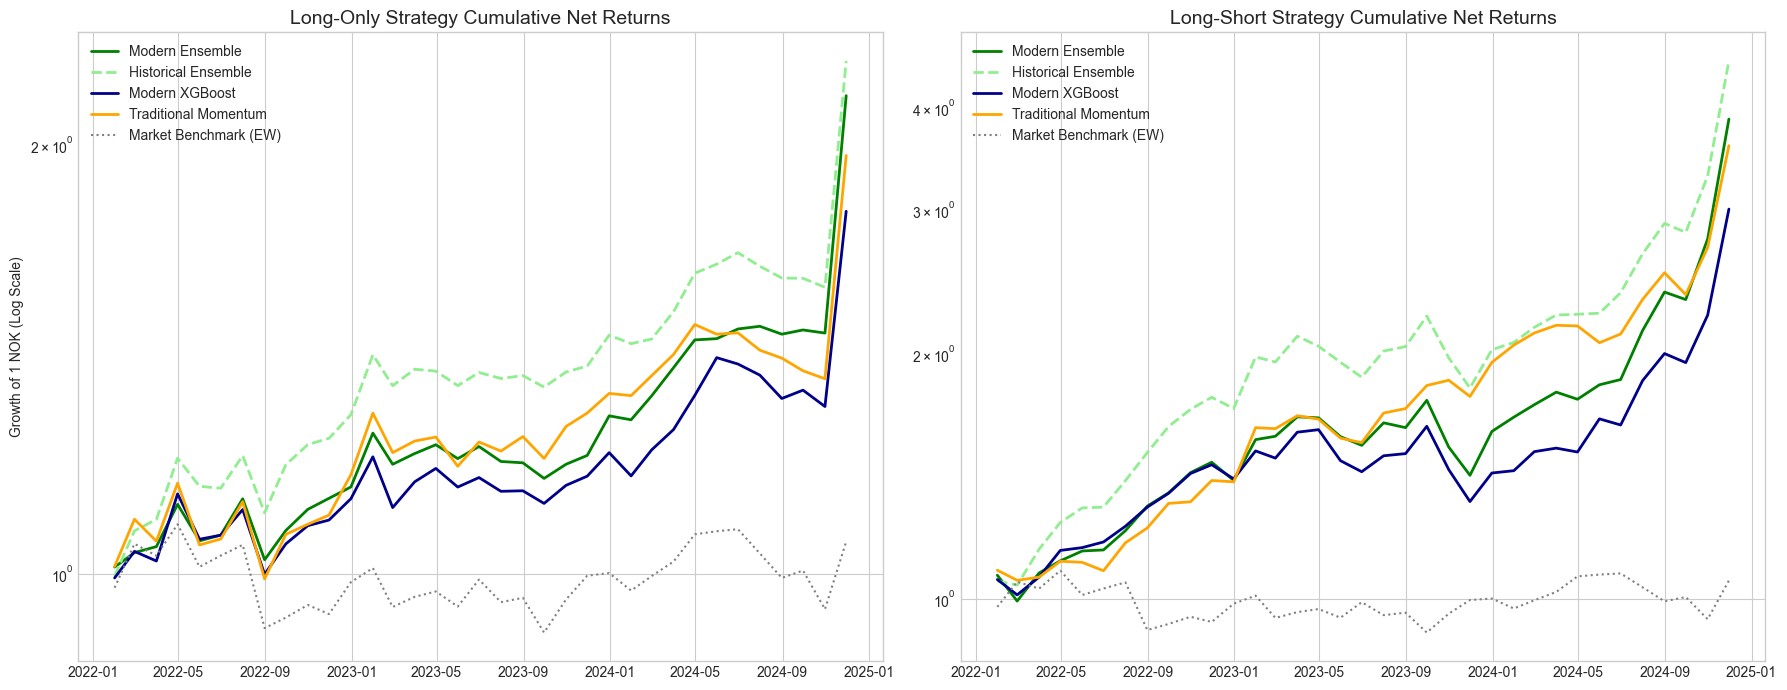


=== SIMULATION SUMMARY STATISTICS ===


,Strategy,Ann_Ret_LongOnly,Ann_Ret_LongShort,Turnover_LongShort
0,Modern Ensemble,30.20%,51.60%,1.37
1,Historical Ensemble,32.07%,57.07%,1.27
2,Modern XGBoost,23.14%,41.77%,1.49
3,Historical XGBoost,31.96%,56.79%,1.40
4,Traditional Momentum,27.15%,47.53%,0.90
5,Market Benchmark (EW),3.06%,N/A,N/A


In [49]:
# ==========================================
# CELL 4: EXECUTION & VISUALIZATION
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt

print("Running simulations... (This may take a few seconds)")

# Test 1: Modern Ensemble
sim_mod_en = run_backtest(df_mod, signal_col='Ensemble_Pred_z', quantile=0.20, tc_rate=TC_BPS)
# Test 2: Historical Ensemble
sim_hist_en = run_backtest(df_hist, signal_col='Ensemble_Pred_z', quantile=0.20, tc_rate=TC_BPS)
# Test 3: Modern XGBoost
sim_mod_xgb = run_backtest(df_mod, signal_col='XGBoost_Pred_z', quantile=0.20, tc_rate=TC_BPS)
# Test 4: Historical XGBoost
sim_hist_xgb = run_backtest(df_hist, signal_col='XGBoost_Pred_z', quantile=0.20, tc_rate=TC_BPS)
# Test 5: Traditional Momentum Baseline (Using Modern Data dates for fair comparison)
sim_mod_mom = run_backtest(df_mod, signal_col='mom_12m_z', quantile=0.20, tc_rate=TC_BPS)

# ---------------------------------------------------------
# VISUALIZATION: Subplots for Long-Only and Long-Short
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Long-Only (Mutual Fund)
axes[0].plot((1 + sim_mod_en['Net_Ret_LongOnly']).cumprod(), label='Modern Ensemble', color='green', linewidth=2)
axes[0].plot((1 + sim_hist_en['Net_Ret_LongOnly']).cumprod(), label='Historical Ensemble', color='lightgreen', linewidth=2, linestyle='--')
axes[0].plot((1 + sim_mod_xgb['Net_Ret_LongOnly']).cumprod(), label='Modern XGBoost', color='darkblue', linewidth=2)
axes[0].plot((1 + sim_mod_mom['Net_Ret_LongOnly']).cumprod(), label='Traditional Momentum', color='orange', linewidth=2)
axes[0].plot((1 + sim_mod_en['Net_Ret_Benchmark']).cumprod(), label='Market Benchmark (EW)', color='gray', linestyle=':')
axes[0].set_title('Long-Only Strategy Cumulative Net Returns', fontsize=14)
axes[0].set_yscale('log')
axes[0].set_ylabel('Growth of 1 NOK (Log Scale)')
axes[0].legend()

# Plot 2: Long-Short (Hedge Fund)
axes[1].plot((1 + sim_mod_en['Net_Ret_LongShort']).cumprod(), label='Modern Ensemble', color='green', linewidth=2)
axes[1].plot((1 + sim_hist_en['Net_Ret_LongShort']).cumprod(), label='Historical Ensemble', color='lightgreen', linewidth=2, linestyle='--')
axes[1].plot((1 + sim_mod_xgb['Net_Ret_LongShort']).cumprod(), label='Modern XGBoost', color='darkblue', linewidth=2)
axes[1].plot((1 + sim_mod_mom['Net_Ret_LongShort']).cumprod(), label='Traditional Momentum', color='orange', linewidth=2)
axes[1].plot((1 + sim_mod_en['Net_Ret_Benchmark']).cumprod(), label='Market Benchmark (EW)', color='gray', linestyle=':')
axes[1].set_title('Long-Short Strategy Cumulative Net Returns', fontsize=14)
axes[1].set_yscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# SUMMARY STATISTICS TABLE
# ---------------------------------------------------------
# Create a clean DataFrame to display the results
summary_data = {
    'Strategy': [
        'Modern Ensemble', 'Historical Ensemble', 
        'Modern XGBoost', 'Historical XGBoost', 
        'Traditional Momentum', 'Market Benchmark (EW)'
    ],
    'Ann_Ret_LongOnly': [
        sim_mod_en['Net_Ret_LongOnly'].mean() * 12,
        sim_hist_en['Net_Ret_LongOnly'].mean() * 12,
        sim_mod_xgb['Net_Ret_LongOnly'].mean() * 12,
        sim_hist_xgb['Net_Ret_LongOnly'].mean() * 12,
        sim_mod_mom['Net_Ret_LongOnly'].mean() * 12,
        sim_mod_en['Net_Ret_Benchmark'].mean() * 12
    ],
    'Ann_Ret_LongShort': [
        sim_mod_en['Net_Ret_LongShort'].mean() * 12,
        sim_hist_en['Net_Ret_LongShort'].mean() * 12,
        sim_mod_xgb['Net_Ret_LongShort'].mean() * 12,
        sim_hist_xgb['Net_Ret_LongShort'].mean() * 12,
        sim_mod_mom['Net_Ret_LongShort'].mean() * 12,
        None # Benchmark cannot be Long-Short
    ],
    'Turnover_LongShort': [
        sim_mod_en['Turnover_LongShort'].mean(),
        sim_hist_en['Turnover_LongShort'].mean(),
        sim_mod_xgb['Turnover_LongShort'].mean(),
        sim_hist_xgb['Turnover_LongShort'].mean(),
        sim_mod_mom['Turnover_LongShort'].mean(),
        None
    ]
}

summary_df = pd.DataFrame(summary_data)
# Format the dataframe for display
summary_df['Ann_Ret_LongOnly'] = summary_df['Ann_Ret_LongOnly'].map('{:.2%}'.format)
summary_df['Ann_Ret_LongShort'] = summary_df['Ann_Ret_LongShort'].apply(lambda x: '{:.2%}'.format(x) if pd.notnull(x) else 'N/A')
summary_df['Turnover_LongShort'] = summary_df['Turnover_LongShort'].apply(lambda x: '{:.2f}'.format(x) if pd.notnull(x) else 'N/A')

print("\n=== SIMULATION SUMMARY STATISTICS ===")
display(summary_df)

In [50]:

# ---------------------------------------------------------
# EXPORT FOR NOTEBOOK 4 (EVALUATION)
# ---------------------------------------------------------
# We will save the Modern Ensemble results as our primary dataset for Notebook 4
# You can easily export the others if you want to run regressions on all of them
final_export_mod = sim_mod_en.copy()
final_export_mod['Net_Ret_Modern_XGB_LS'] = sim_mod_xgb['Net_Ret_LongShort']
final_export_mod['Net_Ret_Mom_LS'] = sim_mod_mom['Net_Ret_LongShort']

final_export_hist = sim_hist_en.copy()
final_export_hist['Net_Ret_Hist_XGB_LS'] = sim_hist_xgb['Net_Ret_LongShort']

final_export_mod.to_csv('../Data/portfolio_simulation_returns_mod.csv')
final_export_hist.to_csv('../Data/portfolio_simulation_returns_hist.csv')

print("\nPortfolio returns exported to 'portfolio_simulation_returns_mod.csv' and 'portfolio_simulation_returns_hist.csv' for Notebook 4!")


Portfolio returns exported to 'portfolio_simulation_returns_mod.csv' and 'portfolio_simulation_returns_hist.csv' for Notebook 4!
